<a href="https://colab.research.google.com/github/zeosapka/glass-box-ai-research/blob/main/notebooks/11_group_intervention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# E10 — Group Intervention
# Amaç:
# Transformer iç temsilindeki 5 boyutluk aday grubun birlikte
# müdahale edildiğinde oluşturduğu L1 çıktı değişimini ölçmek
# ve bunu tekil boyut etkilerinin toplamı ile random-control
# gruplarıyla karşılaştırmak.
# ============================================================

import numpy as np
import pandas as pd
import torch

# Deneyin tekrar üretilebilir olması için sabit seed
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# E10'da test edilecek aday boyut grubu
CANDIDATE_GROUP = [471, 228, 12, 358, 529]

# Random-control grup sayısı
N_RANDOM_GROUPS = 5

# Her random control grubu 5 boyuttan oluşacak
GROUP_SIZE = 5

print("E10 Group Intervention setup hazır.")
print(f"Candidate group: {CANDIDATE_GROUP}")
print(f"Number of random groups: {N_RANDOM_GROUPS}")
print(f"Random group size: {GROUP_SIZE}")
print(f"Seed: {SEED}")

E10 Group Intervention setup hazır.
Candidate group: [471, 228, 12, 358, 529]
Number of random groups: 5
Random group size: 5
Seed: 42


In [2]:
# ============================================================
# E10 — Model Setup
# Amaç:
# E09 ile aynı distilgpt2 modelini yüklemek ve grup
# müdahalesinin uygulanacağı 5. Transformer katmanını
# doğrulamak.
# ============================================================

from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "distilgpt2"

# Tokenizer ve causal language model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)

# GPU varsa GPU, yoksa CPU kullan
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = model.to(device)
model.eval()

# Müdahalenin uygulanacağı Transformer katmanı
TARGET_LAYER = model.transformer.h[5]

# Gizli temsil boyutu
HIDDEN_SIZE = model.config.n_embd

print(f"Model: {MODEL_NAME}")
print(f"Device: {device}")
print(f"Target layer: 5")
print(f"Hidden size: {HIDDEN_SIZE}")

config.json:   0%|          | 0.00/762 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  353MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/76 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Model: distilgpt2
Device: cpu
Target layer: 5
Hidden size: 768


In [3]:
# ============================================================
# E10 — Baseline Output
# Amaç:
# Grup müdahalesi yapılmadan önce modelin normal çıktısını
# hesaplamak. Daha sonra tüm grup müdahaleleri bu baseline
# çıktı ile karşılaştırılacaktır.
# ============================================================

test_sentence = "The cat is sitting on the mat."

# Cümleyi modelin beklediği tensor formatına dönüştür
inputs = tokenizer(
    test_sentence,
    return_tensors="pt"
).to(device)

# Müdahalesiz normal model çıktısı
with torch.no_grad():
    baseline_outputs = model(**inputs)

# Son token için logits
baseline_logits = baseline_outputs.logits[:, -1, :]

# Logits değerlerini olasılığa dönüştür
baseline_probs = torch.softmax(
    baseline_logits,
    dim=-1
)

print(f"Test sentence: {test_sentence}")
print(f"Input shape: {tuple(inputs['input_ids'].shape)}")
print(f"Vocabulary size: {baseline_probs.shape[-1]}")
print(
    f"Baseline probability sum: "
    f"{baseline_probs.sum().item():.6f}"
)

Test sentence: The cat is sitting on the mat.
Input shape: (1, 8)
Vocabulary size: 50257
Baseline probability sum: 1.000016


In [4]:
# ============================================================
# E10 — Group Ablation Function
# Amaç:
# Verilen bir dimension grubunu aynı anda sıfırlayarak
# model çıktısındaki L1 değişimini hesaplamak.
# ============================================================

def calculate_group_ablation_effect(
    dimensions,
    inputs,
    baseline_probs
):
    """
    Verilen hidden dimension grubunu sıfırlar ve
    baseline çıktıya göre L1 değişimini hesaplar.
    """

    def group_ablation_hook(
        module,
        module_input,
        module_output
    ):
        # Transformer katmanının hidden-state çıktısı
        hidden_states = module_output

        # Orijinal tensorü değiştirmemek için kopya oluştur
        modified_hidden = hidden_states.clone()

        # Seçilen tüm dimension'ları aynı anda sıfırla
        modified_hidden[:, :, dimensions] = 0.0

        return modified_hidden

    # Müdahale hook'unu katmana bağla
    hook = TARGET_LAYER.register_forward_hook(
        group_ablation_hook
    )

    try:
        # Müdahaleli model çıktısını hesapla
        with torch.no_grad():
            outputs = model(**inputs)

        intervention_logits = outputs.logits[:, -1, :]

        intervention_probs = torch.softmax(
            intervention_logits,
            dim=-1
        )

    finally:
        # Hook'u mutlaka kaldır
        hook.remove()

    # Baseline ile müdahaleli çıktı arasındaki
    # toplam L1 değişimi
    l1_change = torch.sum(
        torch.abs(
            intervention_probs - baseline_probs
        )
    ).item()

    return l1_change


print("Group ablation function hazır.")

Group ablation function hazır.


In [5]:
# ============================================================
# E10 — Candidate Group Ablation
# Amaç:
# Keşifte belirlenen 5 boyutun birlikte sıfırlanmasının
# model çıktısında oluşturduğu L1 değişimini ölçmek.
# ============================================================

candidate_group_effect = calculate_group_ablation_effect(
    dimensions=CANDIDATE_GROUP,
    inputs=inputs,
    baseline_probs=baseline_probs
)

print("E10 — Candidate Group Ablation")
print("=" * 50)
print(f"Candidate group: {CANDIDATE_GROUP}")
print(f"Group L1 effect: {candidate_group_effect:.6f}")

E10 — Candidate Group Ablation
Candidate group: [471, 228, 12, 358, 529]
Group L1 effect: 0.033458


In [6]:
# ============================================================
# E10 — Individual Candidate Effects
# Amaç:
# Aday gruptaki 5 dimension'ın her birini tek başına
# sıfırlayarak oluşturduğu L1 etkisini ölçmek.
# Daha sonra bu değerlerin toplamını grup etkisiyle
# karşılaştıracağız.
# ============================================================

individual_effects = []

for dimension in CANDIDATE_GROUP:

    effect = calculate_group_ablation_effect(
        dimensions=[dimension],
        inputs=inputs,
        baseline_probs=baseline_probs
    )

    individual_effects.append({
        "dimension": dimension,
        "individual_l1_effect": effect
    })

individual_effects_df = pd.DataFrame(individual_effects)

individual_effect_sum = (
    individual_effects_df["individual_l1_effect"].sum()
)

print("E10 — Individual Candidate Effects")
print("=" * 50)
print(individual_effects_df.to_string(index=False))
print("-" * 50)
print(f"Sum of individual effects: {individual_effect_sum:.6f}")
print(f"Joint group effect: {candidate_group_effect:.6f}")

E10 — Individual Candidate Effects
 dimension  individual_l1_effect
       471              0.001824
       228              0.003006
        12              0.003591
       358              0.032780
       529              0.008693
--------------------------------------------------
Sum of individual effects: 0.049894
Joint group effect: 0.033458


In [7]:
# ============================================================
# E10 — Non-Additive Effect
# Amaç:
# 5 dimension'ın birlikte oluşturduğu etkinin,
# tekil etkilerin basit toplamından ne kadar saptığını
# nicel olarak hesaplamak.
# ============================================================

non_additive_difference = (
    candidate_group_effect - individual_effect_sum
)

non_additive_ratio = (
    candidate_group_effect / individual_effect_sum
)

print("E10 — Non-Additive Analysis")
print("=" * 50)
print(f"Individual effects sum : {individual_effect_sum:.6f}")
print(f"Joint group effect     : {candidate_group_effect:.6f}")
print(f"Difference             : {non_additive_difference:.6f}")
print(f"Joint / individual sum : {non_additive_ratio:.4f}")

E10 — Non-Additive Analysis
Individual effects sum : 0.049894
Joint group effect     : 0.033458
Difference             : -0.016436
Joint / individual sum : 0.6706


In [8]:
# ============================================================
# E10 — Random Control Groups
# Amaç:
# Aday grubun etkisini karşılaştırmak için 5 adet random
# 5-boyutlu kontrol grubu oluşturmak.
# Aday dimension'lar kontrol gruplarından çıkarılır.
# ============================================================

available_dimensions = [
    dim for dim in range(HIDDEN_SIZE)
    if dim not in CANDIDATE_GROUP
]

# Aynı seed ile her çalıştırmada aynı kontrol gruplarını üret
rng = np.random.default_rng(SEED)

# 5 grup x 5 dimension = 25 benzersiz kontrol dimension'ı
random_dimensions = rng.choice(
    available_dimensions,
    size=N_RANDOM_GROUPS * GROUP_SIZE,
    replace=False
)

random_groups = random_dimensions.reshape(
    N_RANDOM_GROUPS,
    GROUP_SIZE
).tolist()

print("E10 — Random Control Groups")
print("=" * 50)

for i, group in enumerate(random_groups, start=1):
    print(f"Control group {i}: {group}")

E10 — Random Control Groups
Control group 1: [524, 283, 151, 601, 139]
Control group 2: [597, 489, 643, 756, 97]
Control group 3: [65, 327, 397, 557, 66]
Control group 4: [545, 343, 577, 323, 382]
Control group 5: [711, 736, 640, 71, 390]


In [9]:
# ============================================================
# E10 — Random Group Ablation Effects
# Amaç:
# Oluşturduğumuz 5 random kontrol grubunun birlikte
# sıfırlanmasıyla oluşan L1 çıktı değişimini ölçmek.
# ============================================================

random_group_effects = []

for group_number, group in enumerate(
    random_groups,
    start=1
):
    effect = calculate_group_ablation_effect(
        dimensions=group,
        inputs=inputs,
        baseline_probs=baseline_probs
    )

    random_group_effects.append({
        "group": group_number,
        "dimensions": group,
        "l1_effect": effect
    })

random_group_effects_df = pd.DataFrame(
    random_group_effects
)

print("E10 — Random Group Ablation Effects")
print("=" * 50)

for _, row in random_group_effects_df.iterrows():
    print(
        f"Control group {int(row['group'])}: "
        f"{row['l1_effect']:.6f}"
    )

print("-" * 50)

random_control_mean = (
    random_group_effects_df["l1_effect"].mean()
)

random_control_std = (
    random_group_effects_df["l1_effect"].std(ddof=1)
)

print(f"Random control mean: {random_control_mean:.6f}")
print(f"Random control std : {random_control_std:.6f}")

E10 — Random Group Ablation Effects
Control group 1: 0.043100
Control group 2: 0.066373
Control group 3: 0.021147
Control group 4: 0.046709
Control group 5: 0.082566
--------------------------------------------------
Random control mean: 0.051979
Random control std : 0.023452


In [10]:
# ============================================================
# E10 — Candidate vs Random Controls
# Amaç:
# Aday grubun etkisini random 5-boyutlu kontrol gruplarıyla
# karşılaştırmak ve z-score değerini hesaplamak.
# ============================================================

candidate_vs_random_z = (
    candidate_group_effect - random_control_mean
) / random_control_std

candidate_percentile = (
    np.mean(
        np.array(
            random_group_effects_df["l1_effect"]
        ) < candidate_group_effect
    ) * 100
)

print("E10 — Candidate vs Random Controls")
print("=" * 50)
print(f"Candidate group effect : {candidate_group_effect:.6f}")
print(f"Random control mean   : {random_control_mean:.6f}")
print(f"Random control std    : {random_control_std:.6f}")
print(f"Z-score               : {candidate_vs_random_z:.4f}")
print(f"Candidate percentile  : {candidate_percentile:.1f}%")
print("-" * 50)

if candidate_vs_random_z >= 2:
    print("Criterion (a): PASS — z >= 2")
else:
    print("Criterion (a): FAIL — z < 2")

E10 — Candidate vs Random Controls
Candidate group effect : 0.033458
Random control mean   : 0.051979
Random control std    : 0.023452
Z-score               : -0.7898
Candidate percentile  : 20.0%
--------------------------------------------------
Criterion (a): FAIL — z < 2


In [11]:
# ============================================================
# E10 — Success Criteria
# Amaç:
# E10'un iki başarı kriterini birlikte değerlendirmek:
# (a) Random gruplara göre güçlü etki (z >= 2)
# (b) Tekil etkilerin toplamından farklı non-additive davranış
# ============================================================

criterion_a = candidate_vs_random_z >= 2

# Birlikte grup etkisinin tekil etkiler toplamından
# anlamlı biçimde farklı olup olmadığını kontrol et.
criterion_b = not np.isclose(
    candidate_group_effect,
    individual_effect_sum
)

print("E10 — Success Criteria")
print("=" * 50)
print(f"Criterion (a) — z >= 2        : {criterion_a}")
print(f"Criterion (b) — non-additive  : {criterion_b}")
print("-" * 50)

if criterion_a or criterion_b:
    print("E10 overall criterion: PASS / SUPPORT")
else:
    print("E10 overall criterion: FAIL")

print("-" * 50)
print(
    f"Joint effect              : "
    f"{candidate_group_effect:.6f}"
)
print(
    f"Individual effects sum    : "
    f"{individual_effect_sum:.6f}"
)
print(
    f"Non-additive difference   : "
    f"{non_additive_difference:.6f}"
)
print(
    f"Joint / individual sum    : "
    f"{non_additive_ratio:.4f}"
)

E10 — Success Criteria
Criterion (a) — z >= 2        : False
Criterion (b) — non-additive  : True
--------------------------------------------------
E10 overall criterion: PASS / SUPPORT
--------------------------------------------------
Joint effect              : 0.033458
Individual effects sum    : 0.049894
Non-additive difference   : -0.016436
Joint / individual sum    : 0.6706


In [12]:
# ============================================================
# E10 — Results Summary
# Amaç:
# Aday grup, tekil boyutlar ve random kontrol gruplarından
# elde edilen temel sonuçları tek bir tabloda toplamak.
# ============================================================

e10_summary = pd.DataFrame({
    "metric": [
        "candidate_group_effect",
        "individual_effect_sum",
        "non_additive_difference",
        "joint_to_individual_ratio",
        "random_control_mean",
        "random_control_std",
        "candidate_vs_random_z",
        "candidate_percentile"
    ],
    "value": [
        candidate_group_effect,
        individual_effect_sum,
        non_additive_difference,
        non_additive_ratio,
        random_control_mean,
        random_control_std,
        candidate_vs_random_z,
        candidate_percentile
    ]
})

print("E10 — Results Summary")
print("=" * 60)
print(e10_summary.to_string(index=False))

E10 — Results Summary
                   metric     value
   candidate_group_effect  0.033458
    individual_effect_sum  0.049894
  non_additive_difference -0.016436
joint_to_individual_ratio  0.670583
      random_control_mean  0.051979
       random_control_std  0.023452
    candidate_vs_random_z -0.789750
     candidate_percentile 20.000000


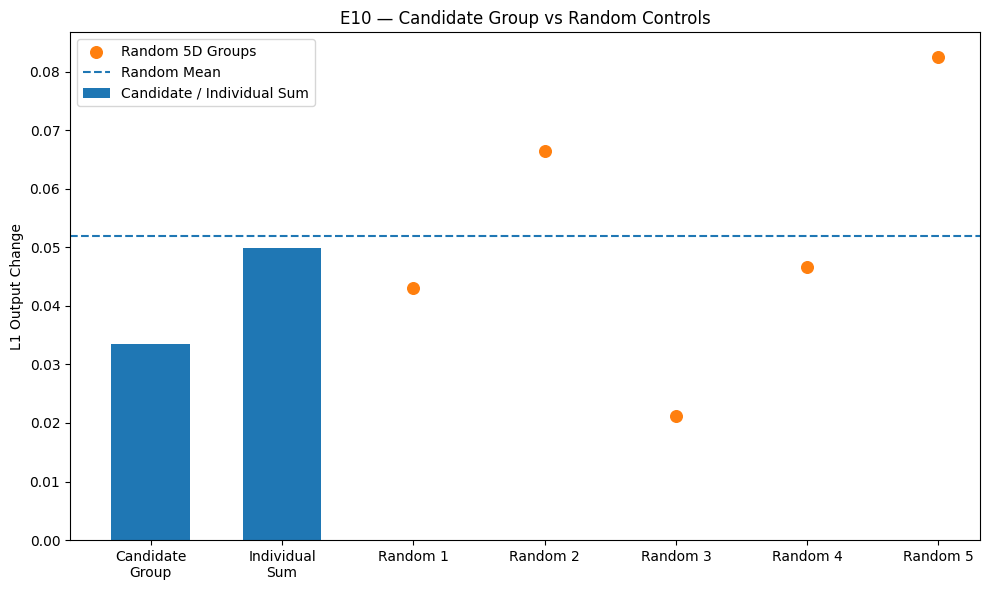

In [14]:
# ============================================================
# E10 — Final Group Effect Comparison
# Amaç:
# Candidate group, individual effect sum ve random kontrol
# gruplarını düzgün etiketlenmiş tek bir grafikte karşılaştırmak.
# Bu grafik E10 sonuç raporunda kullanılacaktır.
# ============================================================

random_effect_values = (
    random_group_effects_df["l1_effect"].to_numpy()
)

plt.figure(figsize=(10, 6))

# Candidate grup ve tekil etkilerin toplamını göster
plt.bar(
    [0, 1],
    [
        candidate_group_effect,
        individual_effect_sum
    ],
    width=0.6,
    label="Candidate / Individual Sum"
)

# Random kontrol gruplarını göster
random_x = np.arange(
    2,
    2 + len(random_effect_values)
)

plt.scatter(
    random_x,
    random_effect_values,
    s=70,
    label="Random 5D Groups"
)

# Random kontrol ortalaması
plt.axhline(
    random_control_mean,
    linestyle="--",
    label="Random Mean"
)

plt.ylabel("L1 Output Change")
plt.title("E10 — Candidate Group vs Random Controls")

plt.xticks(
    range(2 + len(random_effect_values)),
    [
        "Candidate\nGroup",
        "Individual\nSum",
        "Random 1",
        "Random 2",
        "Random 3",
        "Random 4",
        "Random 5"
    ]
)

plt.legend()
plt.tight_layout()
plt.show()

In [15]:
# ============================================================
# E10 — Final Experiment Record
# Amaç:
# E10 deneyinin temel parametrelerini, ölçümlerini ve
# başarı kriterlerini tek bir kayıt yapısında toplamak.
# ============================================================

e10_record = {
    "experiment": "E10",
    "model": MODEL_NAME,
    "target_layer": 5,
    "hidden_size": HIDDEN_SIZE,
    "test_sentence": test_sentence,
    "candidate_group": CANDIDATE_GROUP,
    "candidate_group_effect": candidate_group_effect,
    "individual_effect_sum": individual_effect_sum,
    "non_additive_difference": non_additive_difference,
    "joint_to_individual_ratio": non_additive_ratio,
    "random_control_mean": random_control_mean,
    "random_control_std": random_control_std,
    "candidate_vs_random_z": candidate_vs_random_z,
    "candidate_percentile": candidate_percentile,
    "criterion_a_random_control": criterion_a,
    "criterion_b_non_additive": criterion_b,
    "overall_result": "PASS / SUPPORT"
}

e10_record_df = pd.DataFrame(
    [e10_record]
)

print("E10 — Final Experiment Record")
print("=" * 60)
print(e10_record_df.T.to_string(header=False))

E10 — Final Experiment Record
experiment                                             E10
model                                           distilgpt2
target_layer                                             5
hidden_size                                            768
test_sentence               The cat is sitting on the mat.
candidate_group                   [471, 228, 12, 358, 529]
candidate_group_effect                            0.033458
individual_effect_sum                             0.049894
non_additive_difference                          -0.016436
joint_to_individual_ratio                         0.670583
random_control_mean                               0.051979
random_control_std                                0.023452
candidate_vs_random_z                             -0.78975
candidate_percentile                                  20.0
criterion_a_random_control                           False
criterion_b_non_additive                              True
overall_result            